# Testing Noise Model On ***Phase Flip*** Error Correction Code

In [2]:
# Typical imports

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # Use dark background for plots

import qibo
assert qibo.__version__ >= "0.2.20", "This script requires qibo version 0.2.20 or higher."

from qibo import Circuit, gates
from qibo.result import CircuitResult
from qibo.gates import *

from qibo.ui import plot_circuit, plot_density_hist, visualize_state
from qibo.ui.drawing_utils import QIBO_COMPLEMENTARY_COLOR, QIBO_DEFAULT_COLOR, generate_bitstring_combinations

### Import QEC module ###
from qibo_qec import QEC

custom_style = {                    # Define a custom style for the circuit plot
    "facecolor" : "#000000",
    "edgecolor" : "#ffffff",
    "linecolor" : "#ffffff",
    "textcolor" : "#ffffff",
    "fillcolor" : "#c41b1b",
    "gatecolor" : "#9000ff",
    "controlcolor" : "#360000"
}

Importing Noise Model from Qibo

In [3]:
from qibo.noise import NoiseModel, PauliError, PhaseDampingError, DepolarizingError, AmplitudeDampingError

## Basic Circuit Without Error Correction

Initialized QEC with code type: phase_flip


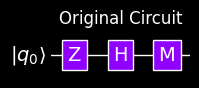

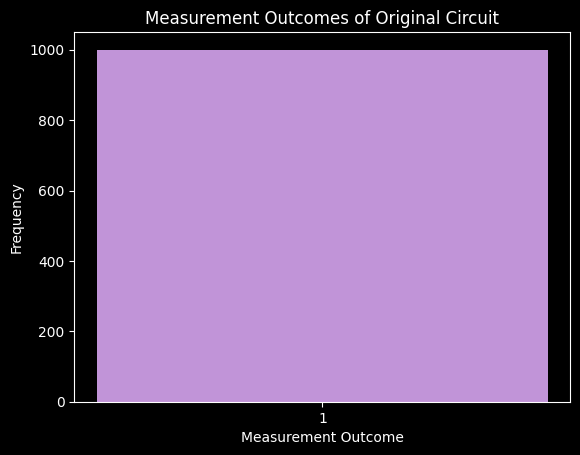

In [ ]:
qc = Circuit(1)
qc.add( [ gates.Z(0), gates.H(0), gates.M(0)] )
plot_circuit(qc, style=custom_style)
plt.title("Original Circuit")

init_state = 1/np.sqrt(2)*np.array([1, 1], dtype=complex)
result = qc(initial_state=init_state, nshots=1000)
fig, ax = plt.subplots()
ax.bar(result.frequencies().keys(), result.frequencies().values(), color=QIBO_DEFAULT_COLOR)
ax.set_xlabel("Measurement Outcome")
ax.set_ylabel("Frequency")
ax.set_title("Measurement Outcomes of Original Circuit")
plt.show()

Modelling Noise as a Pauli Z Gate on one certain cubit

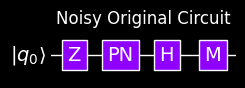

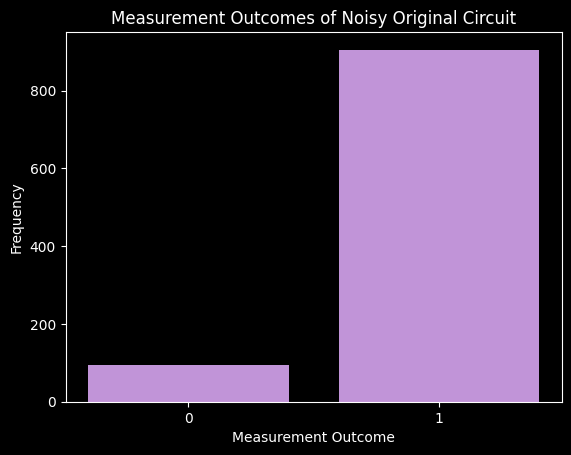

In [18]:
# Probability of phase-flip error
error_rate = 0.1

# Define noise model with phase Flip Error as a Pauli Z gate with certain error probability
noise_model = NoiseModel()
noise_model.add(PauliError([("Z", error_rate)]), gates.Z, 0)

# Apply noise model to original and QEC encoded circuits
qc_noisy = noise_model.apply(qc)
plot_circuit(qc_noisy, style=custom_style)
plt.title("Noisy Original Circuit")

init_state = 1/np.sqrt(2)*np.array([1, 1], dtype=complex)
result_noisy = qc_noisy(initial_state=init_state, nshots=1000)
fig, ax = plt.subplots()
ax.bar(result_noisy.frequencies().keys(), result_noisy.frequencies().values(), color=QIBO_DEFAULT_COLOR)
ax.set_xlabel("Measurement Outcome")
ax.set_ylabel("Frequency")
ax.set_title("Measurement Outcomes of Noisy Original Circuit")
plt.show()

## Adding Phase Flip Error Correction

Initialized QEC with code type: phase_flip
Applying phase_flip code to a circuit with 3 qubit(s).


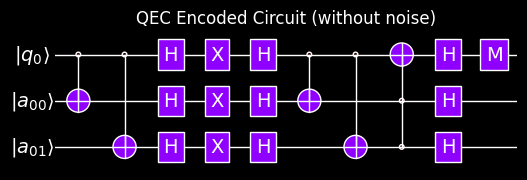

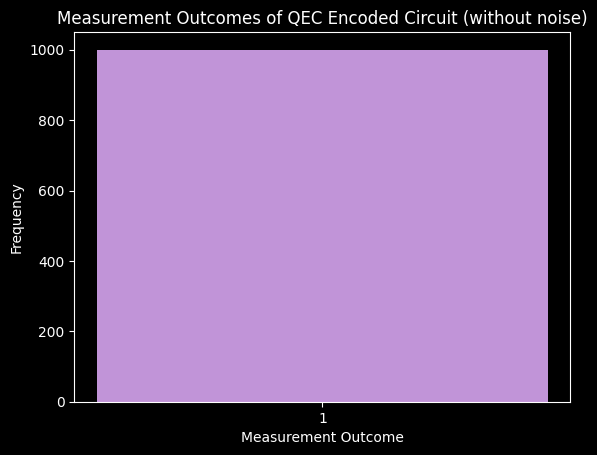

In [23]:
qc = Circuit(1)
qc.add( [ gates.Z(0), gates.M(0)] )

qec = QEC(code_type="phase_flip")    # Create a QEC object for Phase-Flip code

# Apply QEC encoding to the circuit
qc_qec = qec.apply_code(qc, post_gates=[ gates.H(0), gates.H(1), gates.H(2) ])
plot_circuit(qc_qec, style=custom_style)
plt.title("QEC Encoded Circuit (without noise)")
plt.show()

result_qec = qc_qec(initial_state=init_state, nshots=1000)
fig, ax = plt.subplots()
ax.bar(result_qec.frequencies().keys(), result_qec.frequencies().values(), color=QIBO_DEFAULT_COLOR)
ax.set_xlabel("Measurement Outcome")
ax.set_ylabel("Frequency")
ax.set_title("Measurement Outcomes of QEC Encoded Circuit (without noise)")
plt.show()

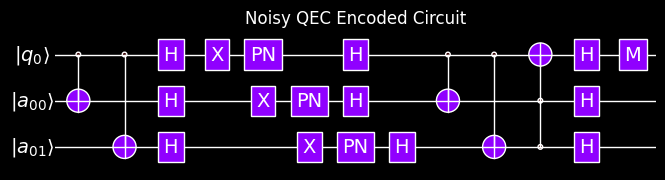

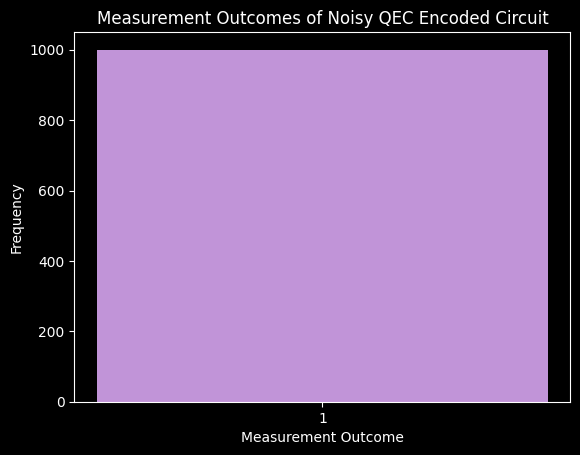

In [24]:
error_rate_qec = 0.1
noise_model_qec = NoiseModel()
noise_model_qec.add(PauliError([("Z", error_rate_qec)]), gates.X)  # Apply noise to the first qubit of the encoded circuit

# Apply noise model to QEC encoded circuit
qc_qec_noisy = noise_model_qec.apply(qc_qec)
plot_circuit(qc_qec_noisy, style=custom_style)
plt.title("Noisy QEC Encoded Circuit")
plt.show()

result_qec_noisy = qc_qec_noisy(initial_state=init_state, nshots=1000)
fig, ax = plt.subplots()
ax.bar(result_qec_noisy.frequencies().keys(), result_qec_noisy.frequencies().values(), color=QIBO_DEFAULT_COLOR)
ax.set_xlabel("Measurement Outcome")
ax.set_ylabel("Frequency")
ax.set_title("Measurement Outcomes of Noisy QEC Encoded Circuit")
plt.show()

Applying phase_flip code to a circuit with 3 qubit(s).


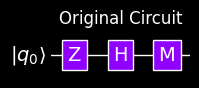

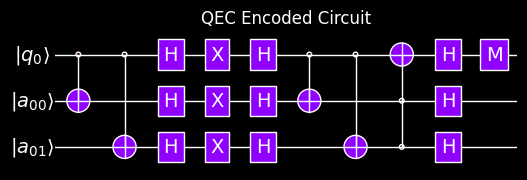

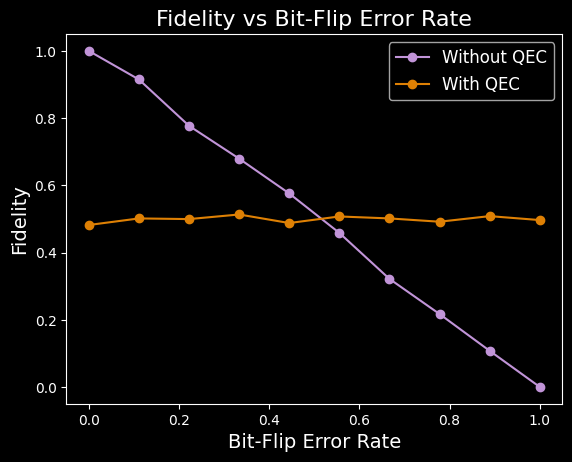

In [28]:
qc = Circuit(1)
qc.add( [ gates.Z(0), gates.H(0), gates.M(0)] )

qc_ = Circuit(1)
qc_.add( [ gates.Z(0), gates.M(0)] )

qc_qec = qec.apply_code(qc_, post_gates=[ gates.H(0), gates.H(1), gates.H(2) ])

initial_state = 1/np.sqrt(2)*np.array([1, 1], dtype=complex)

ranges = np.linspace(0, 1, 10)

fidelitys_no_qec = []
fidelitys_qec = []

plot_circuit(qc, style=custom_style)
plt.title("Original Circuit")
plot_circuit(qc_qec, style=custom_style)
plt.title("QEC Encoded Circuit")
plt.show()

for i in ranges:

    # Define noise model with Bit Flip Error as a Pauli X gate with certain error probability
    noise_model = NoiseModel()
    noise_model.add(PauliError([("Z", i)]), gates.Z, [0,1,2])
    
    qc_noisy = noise_model.apply(qc)
    result = qc_noisy(nshots=2**10, initial_state=initial_state)

    fidelitys_no_qec.append( result.probabilities()[1] )

    # Apply noise model to QEC encoded circuit
    noise_model_qec = NoiseModel()
    noise_model_qec.add(PauliError([("Z", i)]), gates.X, [0,1,2])  # Apply noise to the first qubit of the encoded circuit
    qc_qec_noisy = noise_model_qec.apply(qc_qec)
    
    result_qec = qc_qec_noisy(nshots=2**10)

    fidelitys_qec.append( result_qec.probabilities()[1] )

plt.title("Fidelity vs Bit-Flip Error Rate", fontsize=16)
plt.plot(ranges, fidelitys_no_qec, label="Without QEC", color=QIBO_DEFAULT_COLOR, marker='o')
plt.plot(ranges, fidelitys_qec, label="With QEC", color=QIBO_COMPLEMENTARY_COLOR, marker='o')
plt.xlabel("Bit-Flip Error Rate", fontsize=14)
plt.ylabel("Fidelity", fontsize=14)
plt.legend(fontsize=12)
plt.show()